# Лаба 5: простая нейросеть


In [45]:
import os
import sys

sys.path.append(os.path.abspath(".."))
os.environ.setdefault("MPLCONFIGDIR", "outputs/mpl_cache")
os.makedirs("outputs/mpl_cache", exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import torch
import importlib
import src.models.manual_nn as manual_nn
importlib.reload(manual_nn)

from src.data.mnist_idx import load_mnist_from_folder
from src.metrics.classification_metrics import multiclass_accuracy, multiclass_f1_macro
from src.models.manual_nn import Adam, Dropout, Flatten, Linear, ManualClassifier, ReLU
from src.utils.mnist_drawn_digit import preprocess_drawn_digit

torch.manual_seed(42)
np.random.seed(42)

device = "cpu"
print("device:", device)


device: cpu


In [46]:
DATA_ROOT = os.path.join("..", "datasets", "MNIST_Dataset")
X_train_full, y_train_full, X_test, y_test = load_mnist_from_folder(DATA_ROOT)

print("Train:", tuple(X_train_full.shape), tuple(y_train_full.shape))
print("Test :", tuple(X_test.shape), tuple(y_test.shape))

n_train = int(X_train_full.shape[0])
perm = torch.randperm(n_train)
val_size = 5000
val_idx = perm[:val_size]
train_idx = perm[val_size:]

X_train = X_train_full[train_idx]
y_train = y_train_full[train_idx]
X_val = X_train_full[val_idx]
y_val = y_train_full[val_idx]

print("Split:")
print("  train:", tuple(X_train.shape), tuple(y_train.shape))
print("  val  :", tuple(X_val.shape), tuple(y_val.shape))


Train: (60000, 1, 28, 28) (60000,)
Test : (10000, 1, 28, 28) (10000,)
Split:
  train: (55000, 1, 28, 28) (55000,)
  val  : (5000, 1, 28, 28) (5000,)


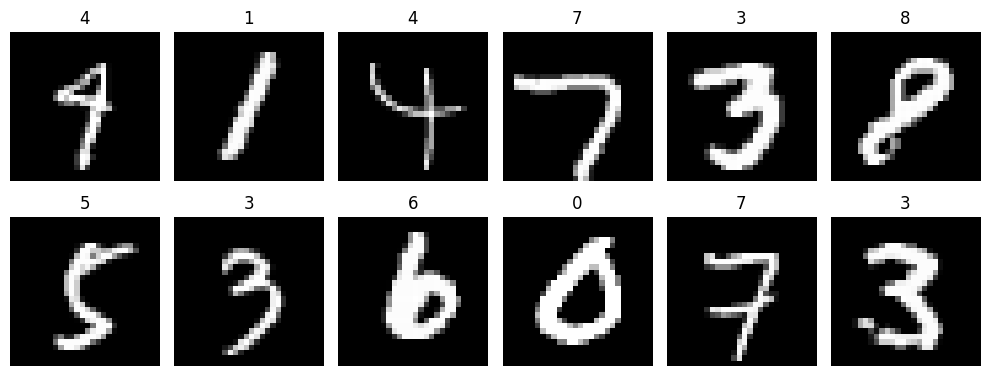

In [47]:
fig, axes = plt.subplots(2, 6, figsize=(10, 4))
axes = axes.flatten()
for i in range(12):
    axes[i].imshow(X_train[i, 0].numpy(), cmap="gray")
    axes[i].set_title(str(int(y_train[i].item())))
    axes[i].axis("off")
plt.tight_layout()
plt.show()


In [48]:
def evaluate(model: ManualClassifier, X: torch.Tensor, y: torch.Tensor) -> dict:
    X = X.to(device=device, dtype=torch.float32)
    y = y.to(device=device, dtype=torch.long)
    with torch.no_grad():
        logits = model.predict_logits(X)
        preds = logits.argmax(dim=1)
    return {
        "accuracy": multiclass_accuracy(preds, y),
        "f1_macro": multiclass_f1_macro(y, preds, n_classes=10),
    }


In [49]:
# Модель A
modelA = ManualClassifier([
    Flatten(),
    Linear(28 * 28, 128),
    ReLU(),
    Linear(128, 10),
])

histA = modelA.fit(
    X_train, y_train, X_val, y_val,
    epochs=3, batch_size=128, lr=5e-4,
    device=device, verbose=True, compute_auc=True, auc_subset=8000,
)

resA = evaluate(modelA, X_test, y_test)
print("Model A test:", resA)


Epoch 1: train_loss=0.4962, train_acc=0.9251, val_loss=0.2820, val_acc=0.9156, train_auc=0.9944, val_auc=0.9947
Epoch 2: train_loss=0.2272, train_acc=0.9455, val_loss=0.2103, val_acc=0.9374, train_auc=0.9971, val_auc=0.9969
Epoch 3: train_loss=0.1740, train_acc=0.9533, val_loss=0.1738, val_acc=0.9476, train_auc=0.9978, val_auc=0.9978
Model A test: {'accuracy': 0.9546999931335449, 'f1_macro': 0.9543007731437683}


In [50]:
# Модель B
modelB = ManualClassifier([
    Flatten(),
    Linear(28 * 28, 256),
    ReLU(),
    Dropout(0.2),
    Linear(256, 128),
    ReLU(),
    Linear(128, 10),
])

histB = modelB.fit(
    X_train, y_train, X_val, y_val,
    epochs=3, batch_size=128, lr=5e-4,
    device=device, verbose=True, compute_auc=True, auc_subset=8000,
)

resB = evaluate(modelB, X_test, y_test)
print("Model B test:", resB)


Epoch 1: train_loss=0.4141, train_acc=0.9502, val_loss=0.1824, val_acc=0.9446, train_auc=0.9972, val_auc=0.9978
Epoch 2: train_loss=0.1659, train_acc=0.9680, val_loss=0.1326, val_acc=0.9598, train_auc=0.9989, val_auc=0.9987
Epoch 3: train_loss=0.1190, train_acc=0.9743, val_loss=0.1101, val_acc=0.9666, train_auc=0.9994, val_auc=0.9992
Model B test: {'accuracy': 0.9702000021934509, 'f1_macro': 0.970027482509613}


In [51]:
# Модель C
modelC = ManualClassifier([
    Flatten(),
    Linear(28 * 28, 300),
    ReLU(),
    Dropout(0.2),
    Linear(300, 150),
    ReLU(),
    Dropout(0.2),
    Linear(150, 60),
    ReLU(),
    Linear(60, 10),
])

histC = modelC.fit(
    X_train, y_train, X_val, y_val,
    epochs=7, batch_size=128, lr=1e-3,
    device=device, verbose=True, compute_auc=True, auc_subset=8000,
)

resC = evaluate(modelC, X_test, y_test)
print("Model C test:", resC)


Epoch 1: train_loss=0.3564, train_acc=0.9613, val_loss=0.1446, val_acc=0.9532, train_auc=0.9983, val_auc=0.9985
Epoch 2: train_loss=0.1425, train_acc=0.9747, val_loss=0.1045, val_acc=0.9654, train_auc=0.9994, val_auc=0.9992
Epoch 3: train_loss=0.1033, train_acc=0.9785, val_loss=0.1012, val_acc=0.9674, train_auc=0.9996, val_auc=0.9994
Epoch 4: train_loss=0.0841, train_acc=0.9838, val_loss=0.0853, val_acc=0.9746, train_auc=0.9998, val_auc=0.9995
Epoch 5: train_loss=0.0692, train_acc=0.9902, val_loss=0.0765, val_acc=0.9760, train_auc=0.9998, val_auc=0.9995
Epoch 6: train_loss=0.0567, train_acc=0.9912, val_loss=0.0807, val_acc=0.9760, train_auc=0.9999, val_auc=0.9995
Epoch 7: train_loss=0.0515, train_acc=0.9912, val_loss=0.0764, val_acc=0.9786, train_auc=0.9999, val_auc=0.9995
Model C test: {'accuracy': 0.9790999889373779, 'f1_macro': 0.9788708209991455}


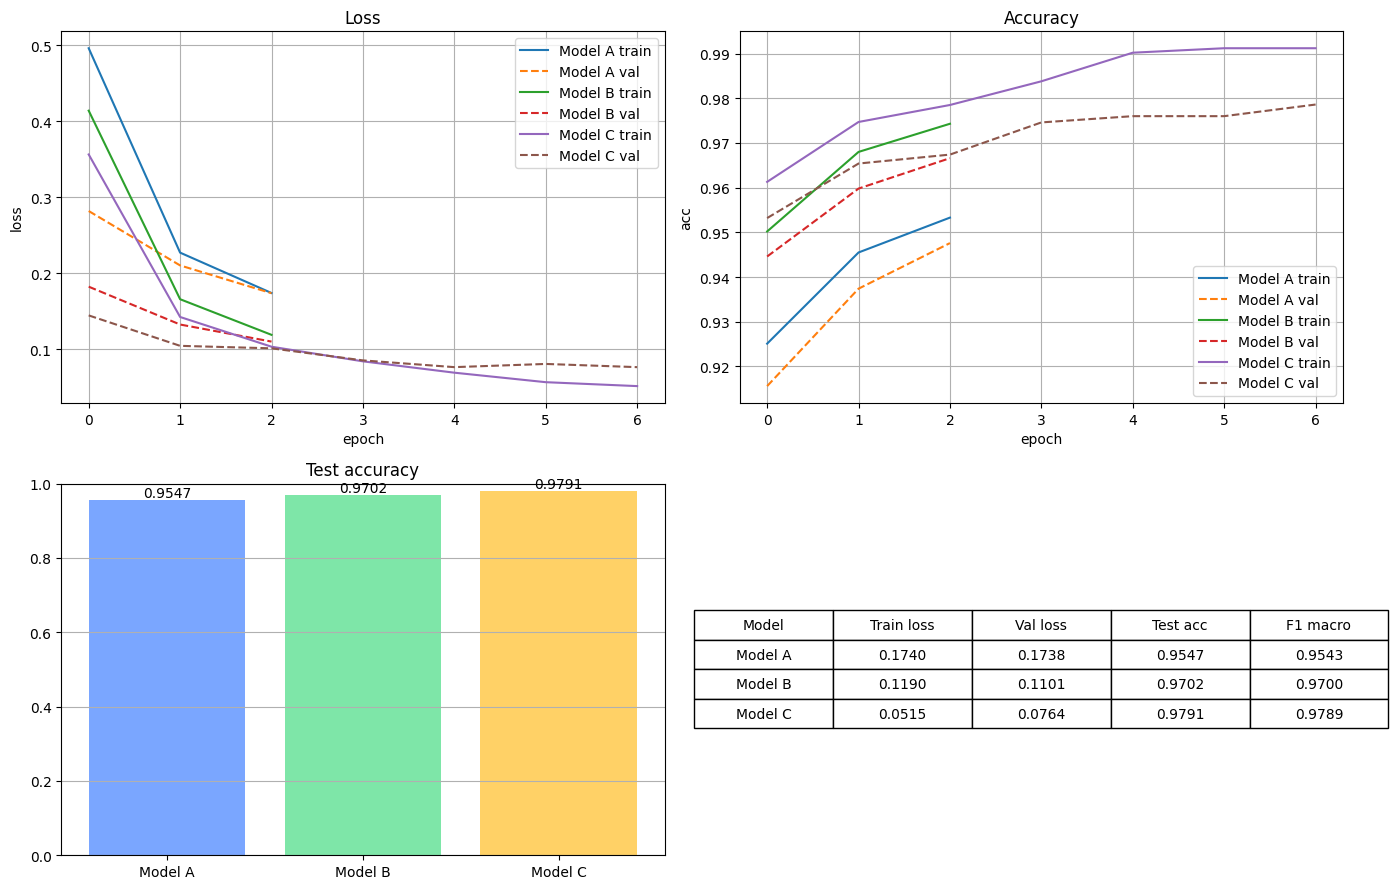

In [52]:
histories = [histA, histB, histC]
names = ["Model A", "Model B", "Model C"]
results = [resA, resB, resC]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax = axes[0, 0]
for h, name in zip(histories, names):
    ax.plot(h["train_loss"], label=f"{name} train")
    if h["val_loss"]:
        ax.plot(h["val_loss"], linestyle="--", label=f"{name} val")
ax.set_title("Loss")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.grid(True)
ax.legend()

ax = axes[0, 1]
for h, name in zip(histories, names):
    ax.plot(h["train_acc"], label=f"{name} train")
    if h["val_acc"]:
        ax.plot(h["val_acc"], linestyle="--", label=f"{name} val")
ax.set_title("Accuracy")
ax.set_xlabel("epoch")
ax.set_ylabel("acc")
ax.grid(True)
ax.legend()

ax = axes[1, 0]
accs = [r["accuracy"] for r in results]
bars = ax.bar(names, accs, color=["#7aa6ff", "#7ee6a8", "#ffd166"])
ax.set_ylim(0, 1)
ax.set_title("Test accuracy")
ax.grid(True, axis="y")
for b, a in zip(bars, accs):
    ax.text(b.get_x() + b.get_width() / 2, a, f"{a:.4f}", ha="center", va="bottom")

ax = axes[1, 1]
ax.axis("off")
table_data = []
for name, h, r in zip(names, histories, results):
    table_data.append([
        name,
        f"{h['train_loss'][-1]:.4f}",
        f"{h['val_loss'][-1]:.4f}" if h["val_loss"] else "-",
        f"{r['accuracy']:.4f}",
        f"{r['f1_macro']:.4f}",
    ])
tbl = ax.table(
    cellText=table_data,
    colLabels=["Model", "Train loss", "Val loss", "Test acc", "F1 macro"],
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.15, 1.5)

plt.tight_layout()
plt.show()


In [53]:
best_i = int(np.argmax([r["accuracy"] for r in results]))
best_name = names[best_i]
best_model = [modelA, modelB, modelC][best_i]
print("best:", best_name, results[best_i])

os.makedirs(os.path.join("..", "outputs", "lab5"), exist_ok=True)
save_path = os.path.join("..", "outputs", "lab5", "best_manual_mlp.pt")
torch.save(best_model.state_dict(), save_path)
print("saved to:", save_path)


best: Model C {'accuracy': 0.9790999889373779, 'f1_macro': 0.9788708209991455}
saved to: ../outputs/lab5/best_manual_mlp.pt


## ROC-кривые (one-vs-rest) и AUC

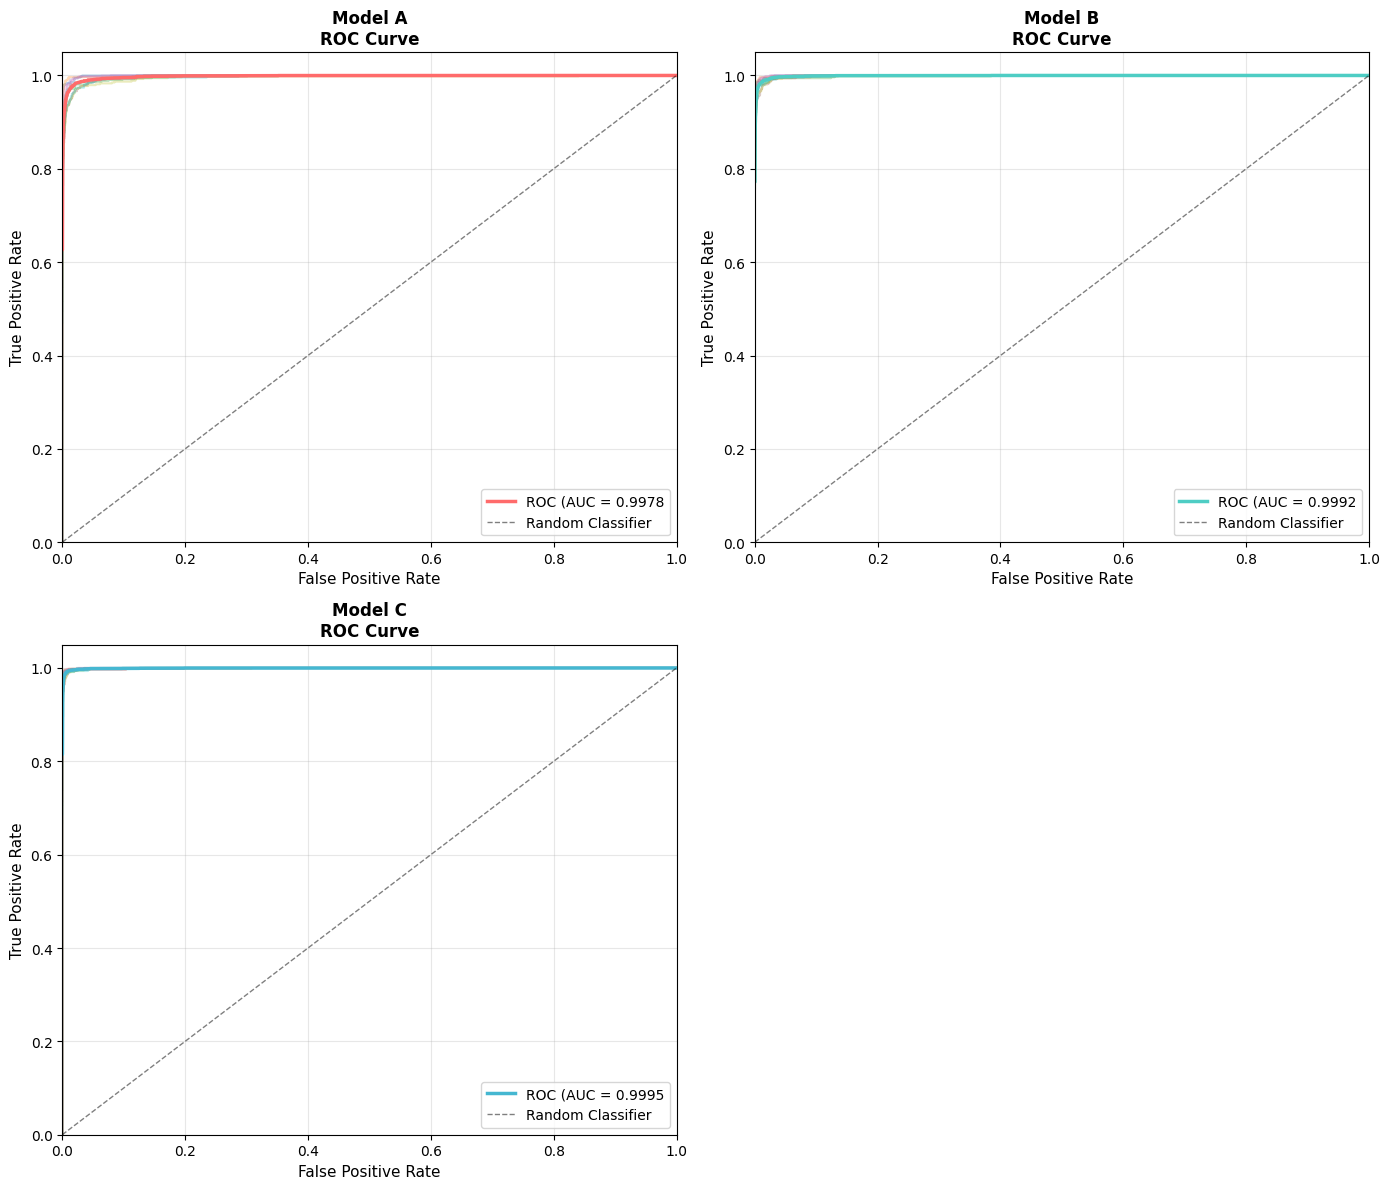

In [ ]:
def compute_roc_curve(y_true, y_scores, num_classes=10):
    roc_curves = []
    for class_idx in range(num_classes):

        y_true_binary = (y_true == class_idx).astype(np.int32)
        y_scores_class = y_scores[:, class_idx]


        sorted_idx = np.argsort(-y_scores_class)
        y_sorted = y_true_binary[sorted_idx]

        n_pos = int(y_true_binary.sum())
        n_neg = int(len(y_true_binary) - n_pos)
        if n_pos == 0 or n_neg == 0:
            continue

        tp = np.cumsum(y_sorted)
        fp = np.cumsum(1 - y_sorted)

        tpr = np.concatenate([[0.0], tp / n_pos])
        fpr = np.concatenate([[0.0], fp / n_neg])

        auc_score = 0.0
        for i in range(len(fpr) - 1):
            auc_score += (fpr[i + 1] - fpr[i]) * (tpr[i] + tpr[i + 1]) / 2.0

        roc_curves.append((fpr, tpr, float(auc_score)))

    return roc_curves


trained_models = {"Model A": modelA, "Model B": modelB, "Model C": modelC}
val_predictions = {}

X_val_eval = X_val.to(device=device, dtype=torch.float32)
y_val_np = y_val.cpu().numpy()

for name, model in trained_models.items():
    with torch.no_grad():
        logits = model.forward(X_val_eval, train=False).cpu().numpy()
    val_predictions[name] = (logits, y_val_np)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for idx, (name, color) in enumerate(zip(trained_models.keys(), colors)):
    ax = axes[idx]

    logits, y_true = val_predictions[name]
    ex = np.exp(logits - logits.max(axis=1, keepdims=True))
    probs = ex / ex.sum(axis=1, keepdims=True)

    roc_curves = compute_roc_curve(y_true, probs, num_classes=10)

    for fpr, tpr, _auc_score in roc_curves:
        ax.plot(fpr, tpr, alpha=0.3, linewidth=1.5)

    max_len = max(len(fpr) for fpr, _, _ in roc_curves)
    fpr_interp = np.linspace(0, 1, max_len)

    tpr_interp_list = []
    for fpr, tpr, _ in roc_curves:
        tpr_i = np.interp(fpr_interp, fpr, tpr)
        tpr_interp_list.append(tpr_i)
    tpr_macro = np.mean(tpr_interp_list, axis=0)

    auc_macro = 0.0
    for i in range(len(fpr_interp) - 1):
        auc_macro += (fpr_interp[i + 1] - fpr_interp[i]) * (tpr_macro[i] + tpr_macro[i + 1]) / 2.0

    ax.plot(fpr_interp, tpr_macro, color=color, linewidth=2.5, label=f'ROC (AUC = {auc_macro:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier')

    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'{name}\nROC Curve', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])

for j in range(len(trained_models), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


## Инференс на нарисованной цифре

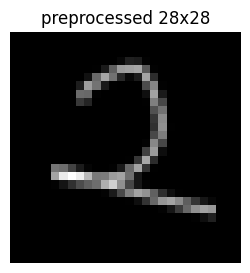

pred: 2


In [55]:
img_path = "my_digit.png"
if os.path.exists(img_path):
    img28 = preprocess_drawn_digit(img_path)
    plt.figure(figsize=(3, 3))
    plt.imshow(img28, cmap="gray")
    plt.title("preprocessed 28x28")
    plt.axis("off")
    plt.show()

    x = torch.from_numpy(img28).view(1, 1, 28, 28).to(device=device, dtype=torch.float32)
    pred = int(best_model.predict(x).item())
    print("pred:", pred)
else:
    print(f"File not found: {img_path}")
